In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# Where can information flow in a packed sequence?

Chapter 8 · Day 11

Loss and visibility are separate controls. Inspect independent conversations, right padding and the attention boundary.

Use the cycle: prediction → inspect mechanism → change one choice → interpret limits. Runnable reference answers follow each question. All computations use CPU; no model download or server is started.

In [2]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/dongxi_llms").is_dir())
sys.path.insert(0, str(root / "src"))
import math, copy, json
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})
from dongxi_llms import evaluation_lab as ev
from dongxi_llms import instruction_data_lab as data
from dongxi_llms import sft_lab as sft
def show_flow(labels, focus):
    fig, ax = plt.subplots(figsize=(11, 1.9))
    for i, label in enumerate(labels):
        ax.text(i, .5, label, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=.45", fc="#dce9f5" if i == focus else "#f6f6f6", ec="#666"))
        if i: ax.annotate("", (i-.25,.5), (i-.75,.5), arrowprops=dict(arrowstyle="->",color="#555"))
    ax.set_xlim(-.6,len(labels)-.4); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title("Schematic process: highlighted component is this lesson's focus")
    plt.show()


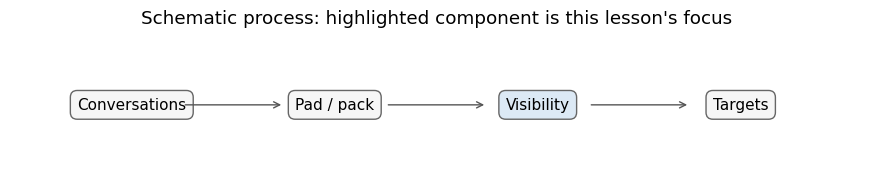

In [3]:
show_flow(["Conversations","Pad / pack","Visibility","Targets"], 2)

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![02 padding packing boundaries: reference plot 01](../figures/chapter-08/day-11-02_padding_packing_boundaries-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

### Prediction

## Predict 1

If two independent conversations are concatenated after an END token, does an ordinary causal triangle isolate them?

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


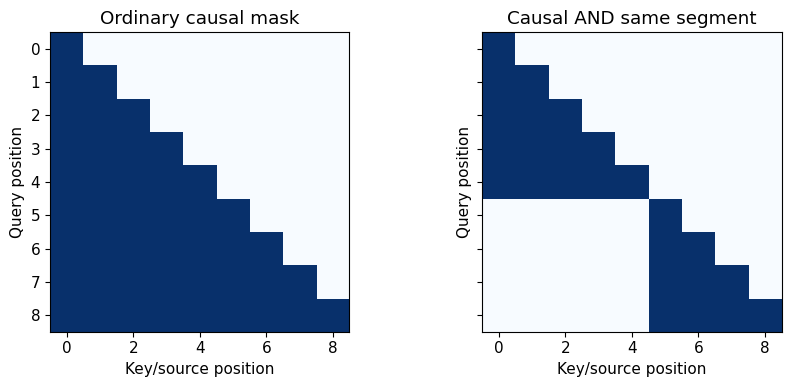

In [4]:
segments = [0]*5+[1]*4
ordinary = np.tril(np.ones((9,9),dtype=bool))
isolated = data.packed_visibility(segments).numpy()
fig,axes = plt.subplots(1,2,figsize=(9,4),sharex=True,sharey=True)
for ax,array,title in zip(axes,[ordinary,isolated],["Ordinary causal mask","Causal AND same segment"]):
    ax.imshow(array,cmap="Blues",vmin=0,vmax=1); ax.set(title=title,xlabel="Key/source position",ylabel="Query position")
plt.tight_layout(); plt.show()
assert ordinary[8,0] and not isolated[8,0]

### Reference explanation

### Reference answer and mechanism

No. END is a learned symbol, not a hard attention barrier. Earlier segments remain visible unless the attention mask excludes them.


**Saved reference preview — rerun the preceding plot cell for current inputs.**

![02 padding packing boundaries: reference plot 02](../figures/chapter-08/day-11-02_padding_packing_boundaries-02.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

### Prediction

## Predict 2

Can zero loss on a padded target substitute for an attention-validity mask? What about real user tokens with zero loss?

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [5]:
short = data.encode_messages([{"role":"user","content":"copy red"},{"role":"assistant","content":"red"}])
batch = data.collate([short,data.instruction_fixture()[1]])
assert torch.all(batch["labels"][~batch["attention_mask"]]==-100)
print("Input IDs:",batch["input_ids"])
print("Valid context:",batch["attention_mask"].int())
print("Supervised labels:",batch["labels"])

Input IDs: tensor([[ 1,  3, 10,  6,  5,  4,  6,  5,  0,  0,  0,  0],
        [ 1,  2, 16, 17,  5,  3, 10,  7,  5,  4,  7,  5]])
Valid context: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)
Supervised labels: tensor([[-100, -100, -100, -100, -100, -100,    6,    5, -100, -100, -100, -100],
        [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100,    7,    5]])


### Reference explanation

### Reference answer and mechanism

No. Loss masking decides which outputs are scored; visibility decides usable context. Real user tokens remain visible even when their own predictions are ignored.


### Prediction

## Predict 3

If a tokenizer reuses END as padding, why should the mask come from lengths rather than ID equality?

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [6]:
fake_ids = torch.tensor([[7,5,5,5]])
valid = torch.tensor([[1,1,0,0]],dtype=torch.bool)
wrong = fake_ids!=5
assert not wrong[0,1] and valid[0,1]
print("Wrong ID-only validity:",wrong.int(),"length-based:",valid.int())

Wrong ID-only validity: tensor([[1, 0, 0, 0]], dtype=torch.int32) length-based: tensor([[1, 1, 0, 0]], dtype=torch.int32)


### Reference explanation

### Reference answer and mechanism

An actual answer ending and a padded slot can have the same ID. The sequence length identifies which is real and preserves the ending target.

## Reading the evidence

The figures are regenerated from the current lesson tensors or declared fixture. Axes and counts define the comparison. Change one control, rerun the relevant cell, and explain what changed in the mechanism. Separate a verified implementation property from a claim about a real language model.

Return to the corresponding chapter and worked solution for the complete argument.
